# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "AlexNet"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [3]:
recompute, storeall = [
    ragdoll.compile(x, "gpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
]

In [4]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable(recompute)
storeall_fb = load_executable(storeall)

## Experimental

In [5]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.alexnet().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")

device = torch.device("cuda:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)
grad = torch.randn_like(output_native)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

df = pd.DataFrame()

Process ForkProcess-5:
Process ForkProcess-12:
Process ForkProcess-11:
Process ForkProcess-22:
Process ForkProcess-7:
Process ForkProcess-13:
Process ForkProcess-28:
Process ForkProcess-3:
Process ForkProcess-23:
Process ForkProcess-10:
Process ForkProcess-6:
Process ForkProcess-9:
Process ForkProcess-1:
Process ForkProcess-8:
Process ForkProcess-4:
Process ForkProcess-2:
Process ForkProcess-20:
Process ForkProcess-30:
Process ForkProcess-25:
Process ForkProcess-32:
Process ForkProcess-19:
Process ForkProcess-27:
Process ForkProcess-31:
Process ForkProcess-24:
Process ForkProcess-26:
Process ForkProcess-29:
Process ForkProcess-21:
Process ForkProcess-18:
Process ForkProcess-17:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last)

### PyTorch (Baseline)

In [6]:
baseline_f = torch_model_benchmark(model_native, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_native, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [0.8743671042954221, 0.874142545987578, 0.8736167870023671, 0.8738697780405774, 0.8724504972205442, 0.872192411300014, 0.8727516978979111, 0.872088157955338, 0.8724569616948857, 0.8734783486408345, 0.8733351988827481]
0.8731590444471109
torch-native-gpu-backward:  [0.867238816092996, 0.8573447189786855, 0.8581208393854253, 0.8587100378730718, 0.8580902153078248, 0.8586912470705369, 0.8577406954239396, 0.8577419006649186, 0.8577489677597495, 0.8576623547603103, 0.8583383853821194]
0.8588571071545071
       time      pass          item
0  0.873159   Forward  Torch Native
0  0.858857  Backward  Torch Native
0  1.732016      Full  Torch Native


In [7]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [0.9148149915477809, 0.9051065015442231, 0.8474363233236706, 0.8383637075038517, 0.8389930624295684, 0.8388322175425641, 0.8391922558931744, 0.8389777229989276, 0.8383501759346793, 0.8382103679811254, 0.8379940820090911]
0.8523883098826052
torch-dynamo-gpu-backward:  [1.6885115491116747, 1.6877083107829094, 1.6883395283537752, 1.687730717308381, 1.6883760690689087, 1.68879861559938, 1.6878114684539682, 1.6882718157242327, 1.6888552071417078, 1.68897069114096, 1.6890049857251783]
1.6883980871282795
       time      pass          item
0  0.873159   Forward  Torch Native
0  0.858857  Backward  Torch Native
0  1.732016      Full  Torch Native
0  0.852388   Forward  Torch Dynamo
0  1.688398  Backward  Torch Dynamo
0  2.540786      Full  Torch Dynamo


### Nabla without Optim

In [8]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)


print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

f2 = np.mean(f2)

print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [0.29936415143311024, 0.29237800496904287, 0.29204892432864976, 0.29182950527790713, 0.2919495642623481, 0.2920781508745516, 0.292563136009609, 0.2933044813792495, 0.2923744626562385, 0.29229310834232497, 0.2922174520790577]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.24, 0.24, 0.24, 0.241, 0.241, 0.241, 0.241, 0.241, 0.241, 0.241, 0.241]
0.2929455401465535
0.24072727272727273


In [9]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
# TODO(albert): unresolved value error
"""
b2 = ragdoll_model_benchmark(
    recompute,
    "dforward",
    [(1, 1000)],
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print(b2)
"""
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [0.8426215735209339, 0.8403351015466101, 0.8403400068773943, 0.8402502043720554, 0.8402638252386275, 0.8402830921113491, 0.8402793964042383, 0.8403108433327254, 0.8403043207876822, 0.8402332674492808, 0.8402762200464221]
       time      pass          item
0  0.873159   Forward  Torch Native
0  0.858857  Backward  Torch Native
0  1.732016      Full  Torch Native
0  0.852388   Forward  Torch Dynamo
0  1.688398  Backward  Torch Dynamo
0  2.540786      Full  Torch Dynamo
0  0.240727   Forward    Nabla-opt1
0  0.840500  Backward    Nabla-opt1
0  1.081227      Full    Nabla-opt1


### Nabla with Optim

In [10]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla-opt2")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [0.3586811725707615, 0.3573017151040189, 0.3572400034788777, 0.3571475445128539, 0.35721029976711555, 0.35711776465177536, 0.35800277091124477, 0.35782011773656397, 0.35722581121851416, 0.3571580580490477, 0.35717270446612553]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.306, 0.306, 0.306, 0.306, 0.306, 0.306, 0.306, 0.305, 0.303, 0.303, 0.303]
ragdoll-opt1-gpu-forward in timeit:  [4.5359037953483705, 4.541568117873633, 4.542664124027771, 4.53858242589323, 4.536234224762986, 4.529485640061252, 4.537974461255705, 4.538962938548887, 4.540016728398554, 4.5377605802872605, 4.538023866274777]
       time      pass          item
0  0.873159   Forward  Torch Native
0  0.858857  Backward  Torch Native
0  1.732016      Full  Torch Native
0  0.852388   Forward  Torch Dynamo
0  1.688398  Backward  Torch Dynamo
0  2.540786      Full  Torch Dynamo
0  0.240727   Forward    Nabla-opt1
0  0.840500  Backward    Nabla-opt1
0  1.0812

In [11]:
df.style.hide(axis="index")

time,pass,item
0.873159,Forward,Torch Native
0.858857,Backward,Torch Native
1.732016,Full,Torch Native
0.852388,Forward,Torch Dynamo
1.688398,Backward,Torch Dynamo
2.540786,Full,Torch Dynamo
0.240727,Forward,Nabla-opt1
0.840500,Backward,Nabla-opt1
1.081227,Full,Nabla-opt1
0.305091,Forward,Nabla-opt2


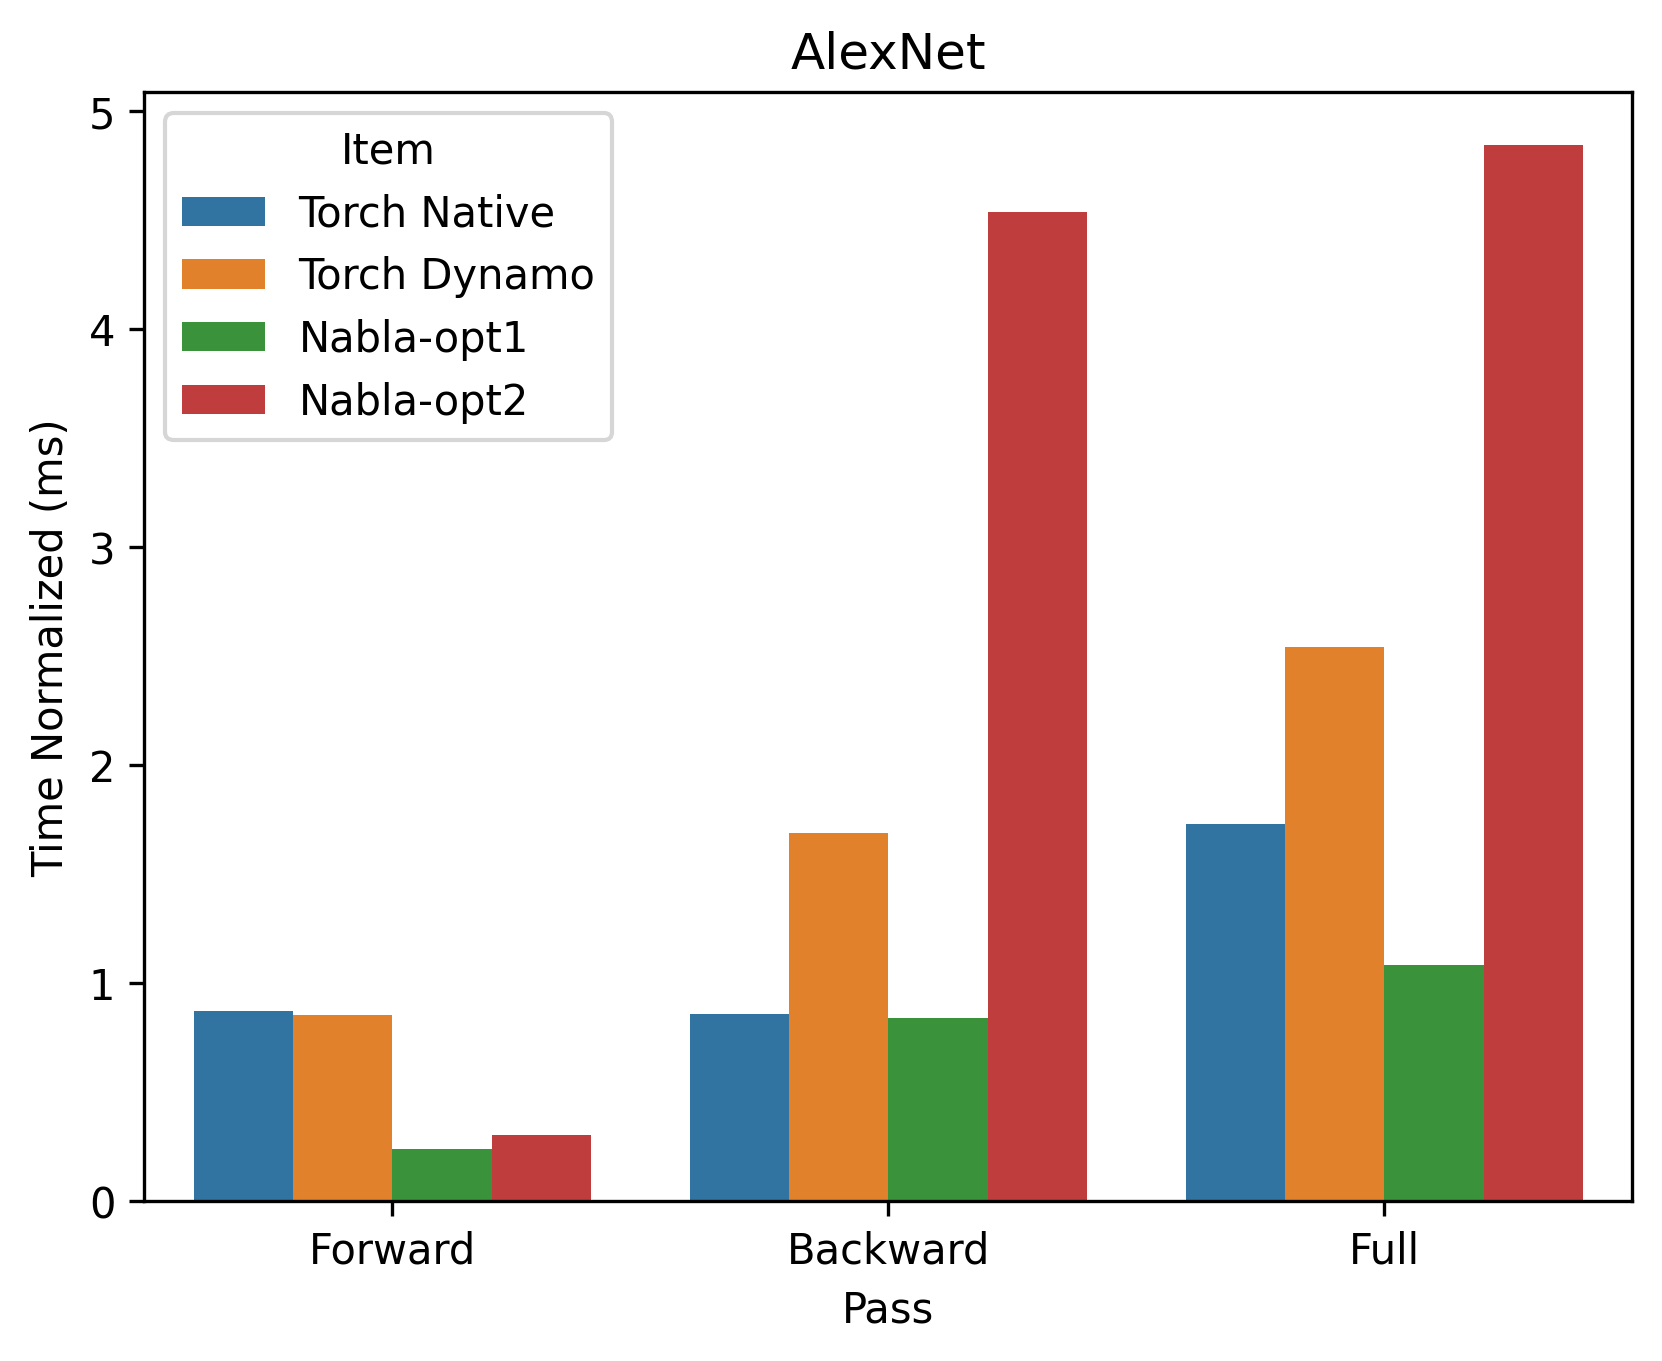

In [12]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [13]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,0.873159,Forward,Torch Native,0.976212
0,0.852388,Forward,Torch Dynamo,1.000000
0,0.240727,Forward,Nabla-opt1,3.540888
0,0.305091,Forward,Nabla-opt2,2.793883


In [14]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,0.858857,Backward,Torch Native,1.965866
0,1.688398,Backward,Torch Dynamo,1.000000
0,0.840500,Backward,Nabla-opt1,2.008802
0,4.537925,Backward,Nabla-opt2,0.372064


In [15]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,1.732016,Full,Torch Native,1.466953
0,2.540786,Full,Torch Dynamo,1.000000
0,1.081227,Full,Nabla-opt1,2.349910
0,4.843016,Full,Nabla-opt2,0.524629


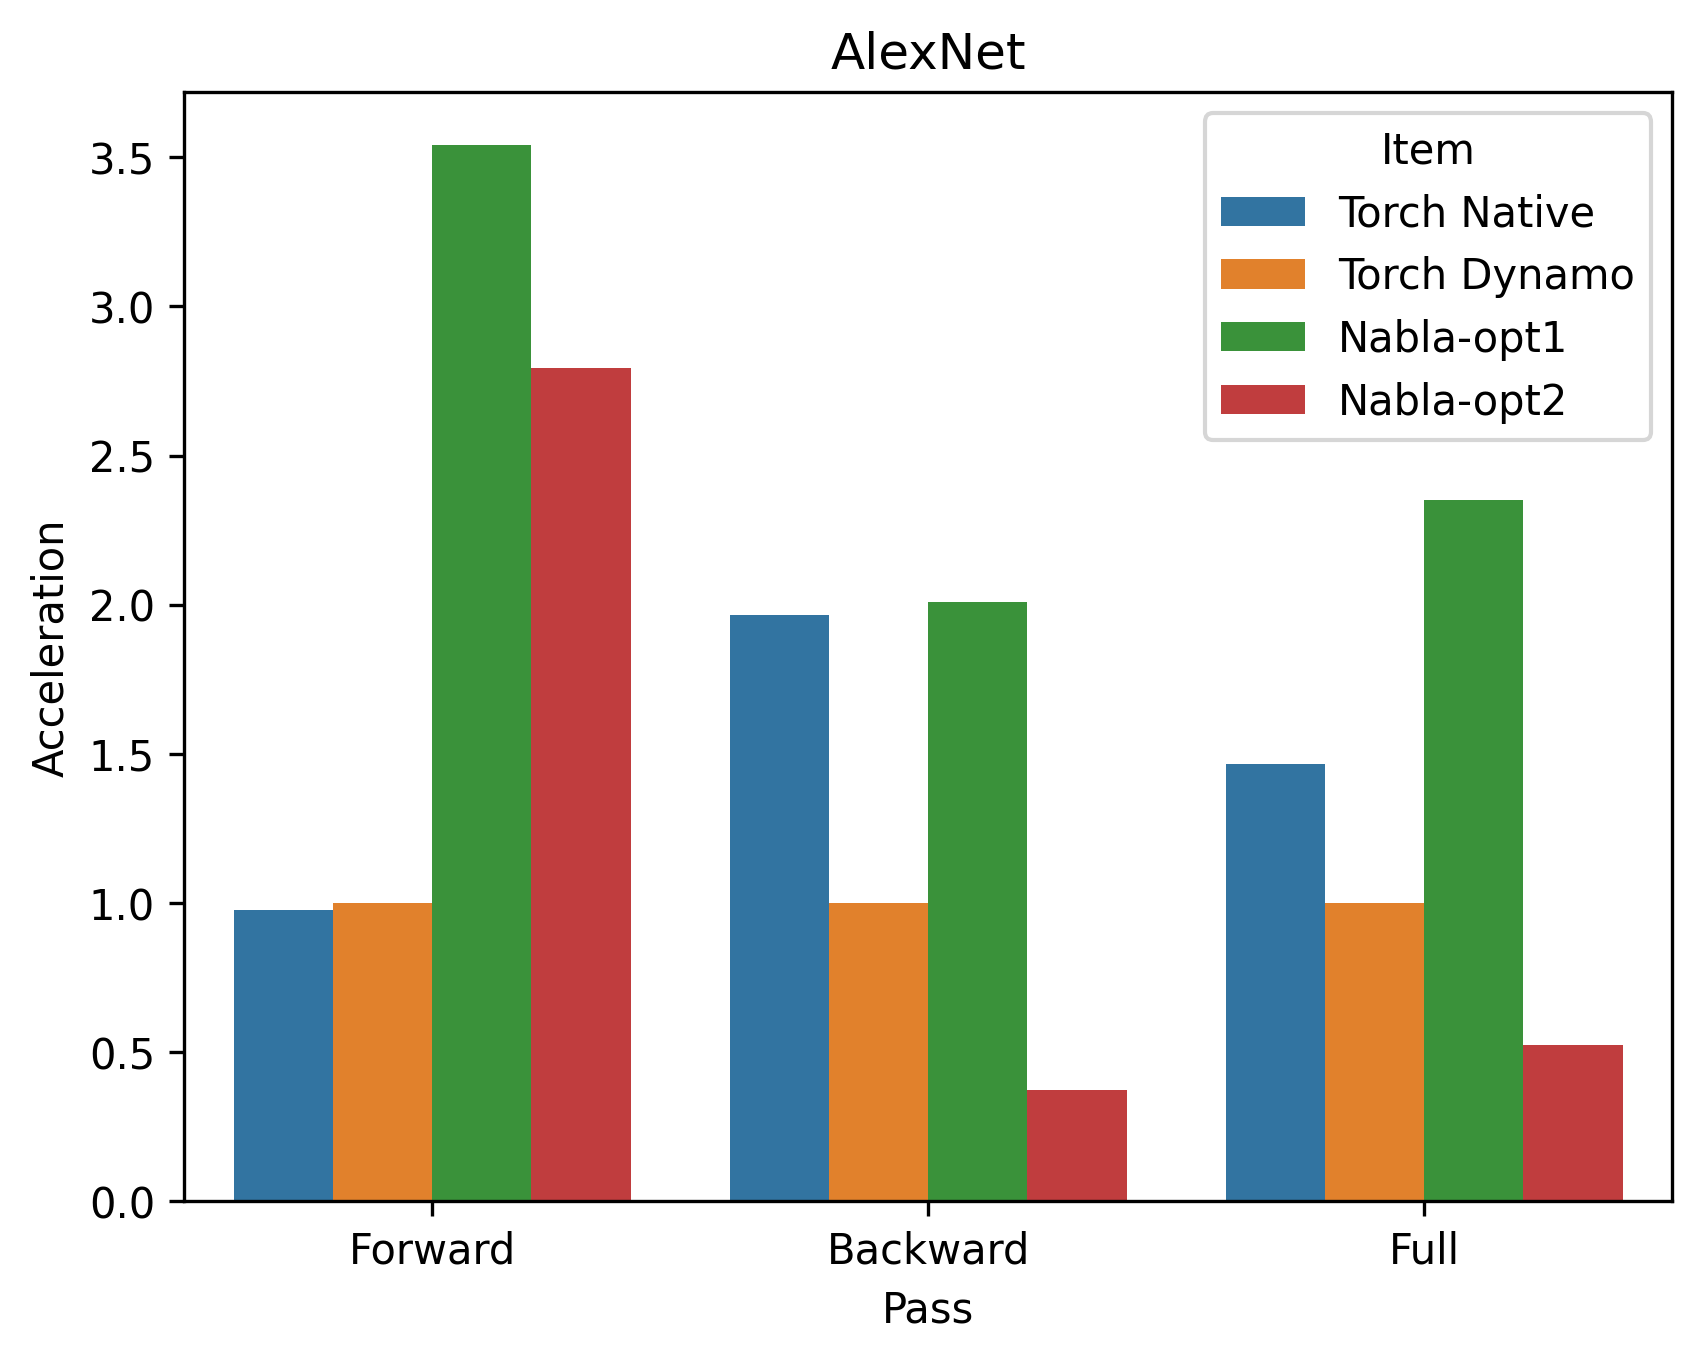

In [16]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")